## Key EDA Findings

### 1. Survival
Approximately 38.4% of passengers survived, indicating that the majority of passengers did not survive.

### 2. Passenger Class
Third-class passengers formed the largest group with 491 passengers, compared with 216 first-class and 184 second-class passengers.

### 3. Survival by Passenger Class
Survival varied significantly by passenger class:
- First Class: 62.96%
- Second Class: 47.28%
- Third Class: 24.24%

### 4. Survival by Gender and Class
Female passengers had substantially higher survival rates than male passengers across all passenger classes.

- Female, First Class: 96.81%
- Female, Second Class: 92.11%
- Female, Third Class: 50.00%
- Male, First Class: 36.89%
- Male, Second Class: 15.74%
- Male, Third Class: 13.54%

### 5. Family Size
Passengers with moderate family sizes showed higher survival rates in this dataset. Family size 4 had the highest observed survival rate at 72.41%.

Larger family sizes had lower observed survival rates, although these groups contain relatively few passengers and therefore should be interpreted cautiously.

### 6. Missing Values
The Cabin column has a high percentage of missing values (77.10%), while Age has 19.87% missing values and Embarked has only 0.22% missing values.

### 7. Fare Outliers
The IQR method identified 116 potential fare outliers. These values should not automatically be treated as errors because they may represent legitimate high-fare passengers.

### 8. Duplicate Records
No duplicate rows were found in the dataset.

In [1]:
# Task 5 - Exploratory Data Analysis
# Titanic Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Titanic dataset

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# Display the first 5 rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Statistical summary of numerical columns

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Check missing values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
# Missing value percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage.sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
dtype: float64

In [8]:
# Distribution of passengers by sex

df["Sex"].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [9]:
# Distribution of passengers by class

df["Pclass"].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [10]:
# Distribution of passengers by embarkation port

df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

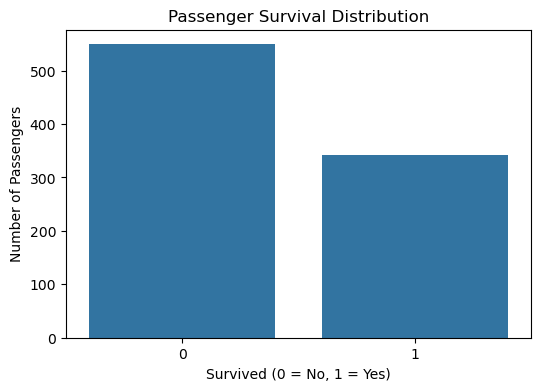

In [11]:
# Survival distribution

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Survived")

plt.title("Passenger Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()

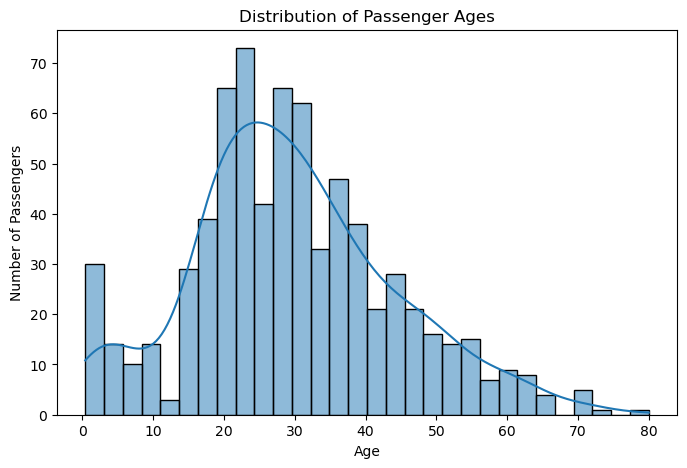

In [12]:
# Age distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=30, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

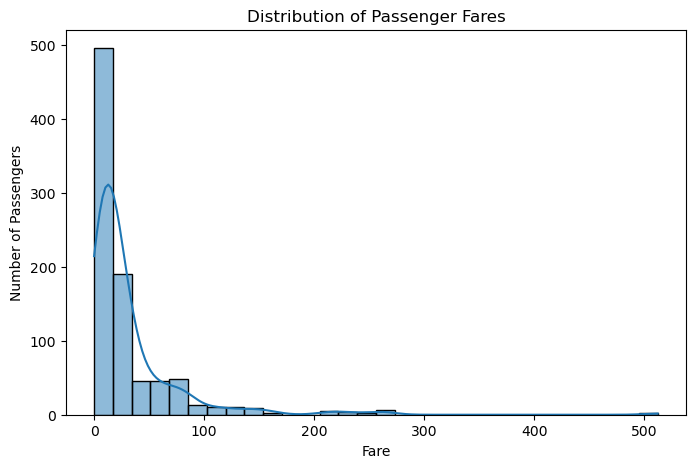

In [13]:
# Fare distribution

plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Fare", bins=30, kde=True)

plt.title("Distribution of Passenger Fares")
plt.xlabel("Fare")
plt.ylabel("Number of Passengers")

plt.show()

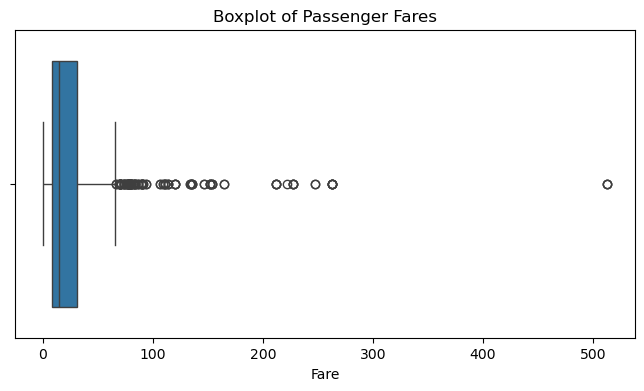

In [14]:
# Fare boxplot

plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="Fare")

plt.title("Boxplot of Passenger Fares")
plt.xlabel("Fare")

plt.show()

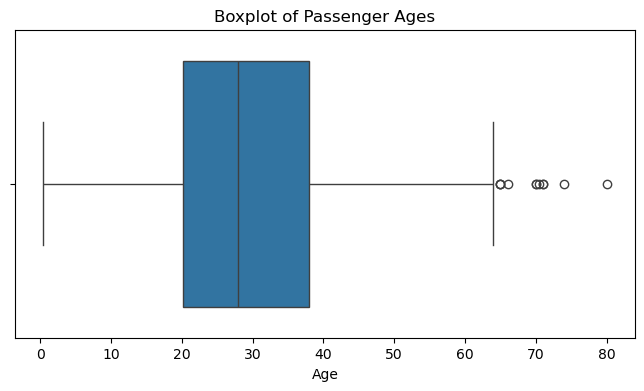

In [15]:
# Age boxplot

plt.figure(figsize=(8, 4))

sns.boxplot(data=df, x="Age")

plt.title("Boxplot of Passenger Ages")
plt.xlabel("Age")

plt.show()

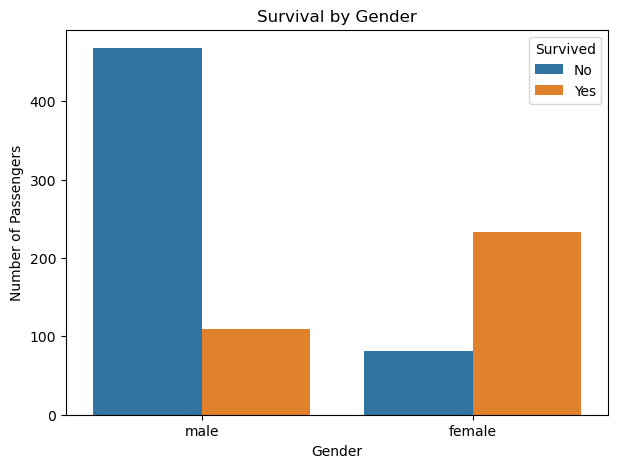

In [16]:
# Survival by gender

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Sex", hue="Survived")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

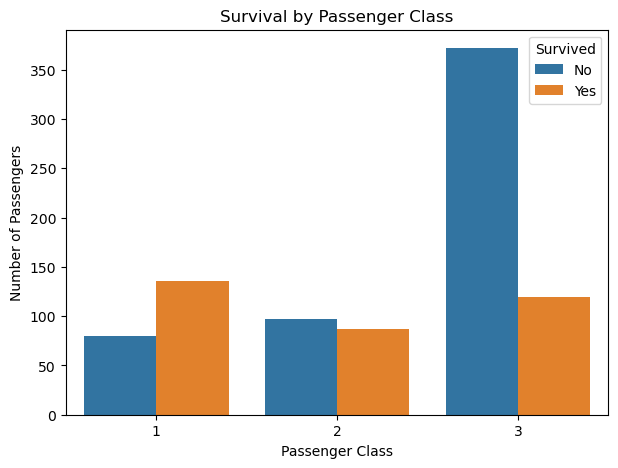

In [17]:
# Survival by passenger class

plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Pclass", hue="Survived")

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

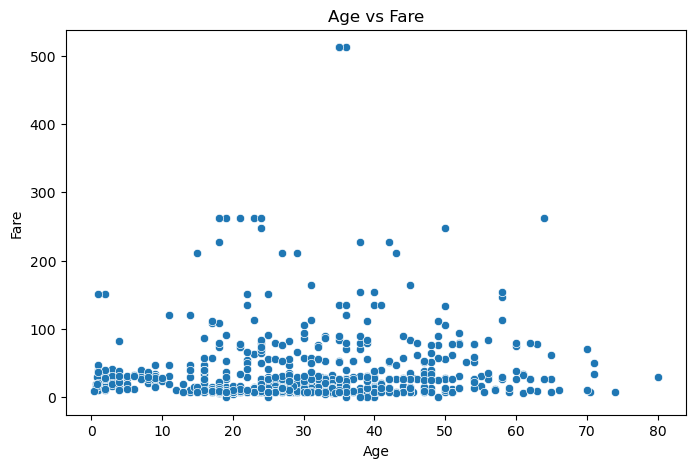

In [18]:
# Age vs Fare scatterplot

plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Age", y="Fare")

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

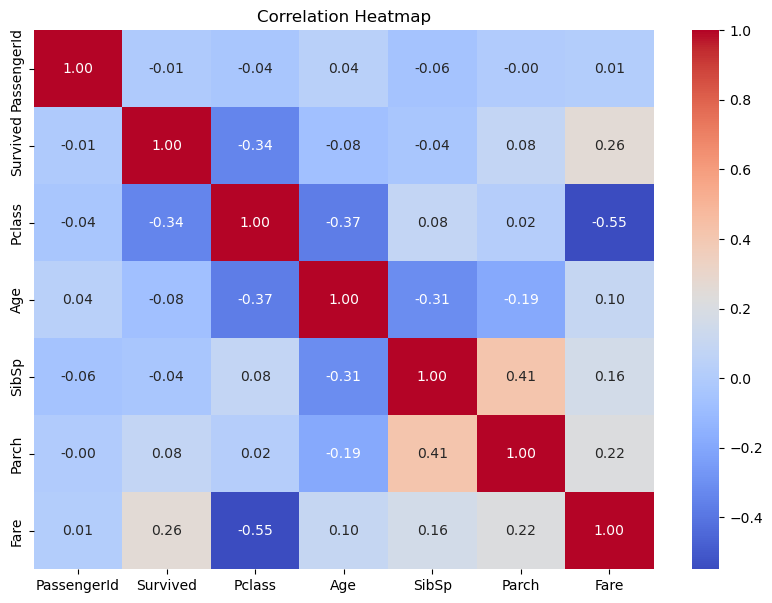

In [19]:
# Correlation matrix

correlation_matrix = df.select_dtypes(include="number").corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

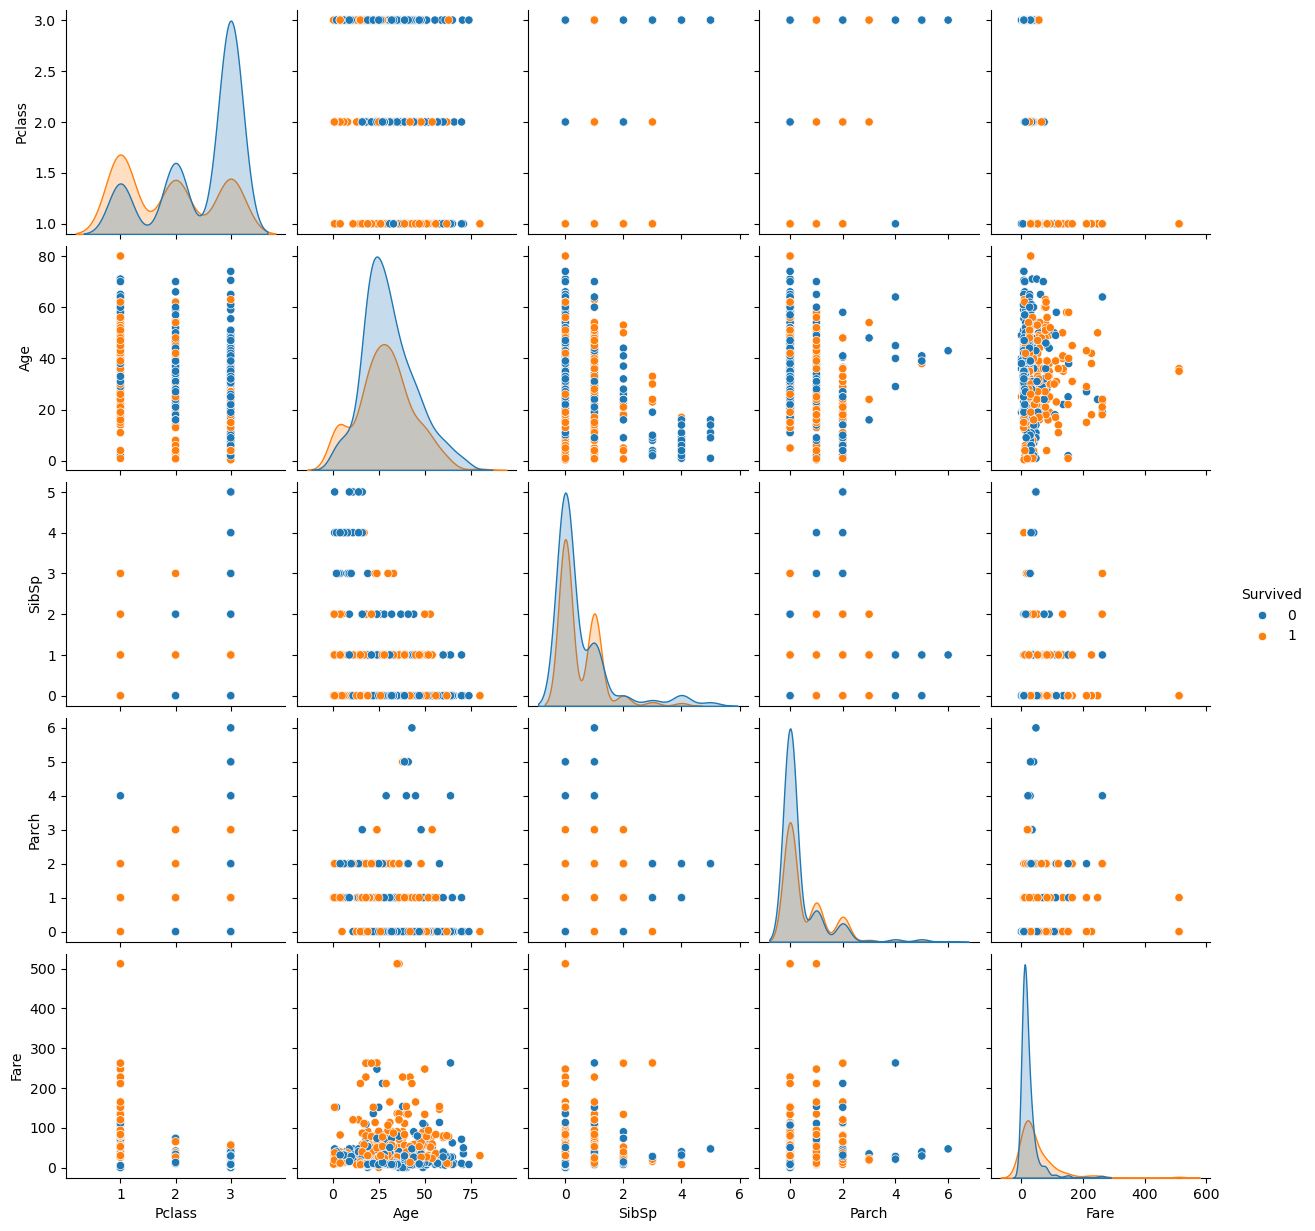

In [20]:
# Pairplot of important numerical variables

sns.pairplot(
    df[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare"]].dropna(),
    hue="Survived"
)

plt.show()

In [21]:
# Survival rate by gender

survival_by_gender = df.groupby("Sex")["Survived"].mean() * 100

survival_by_gender

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

In [22]:
# Survival rate by passenger class

survival_by_class = df.groupby("Pclass")["Survived"].mean() * 100

survival_by_class

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

In [23]:
# Survival rate by gender and passenger class

survival_gender_class = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean() * 100
)

survival_gender_class

Sex     Pclass
female  1         96.808511
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: Survived, dtype: float64

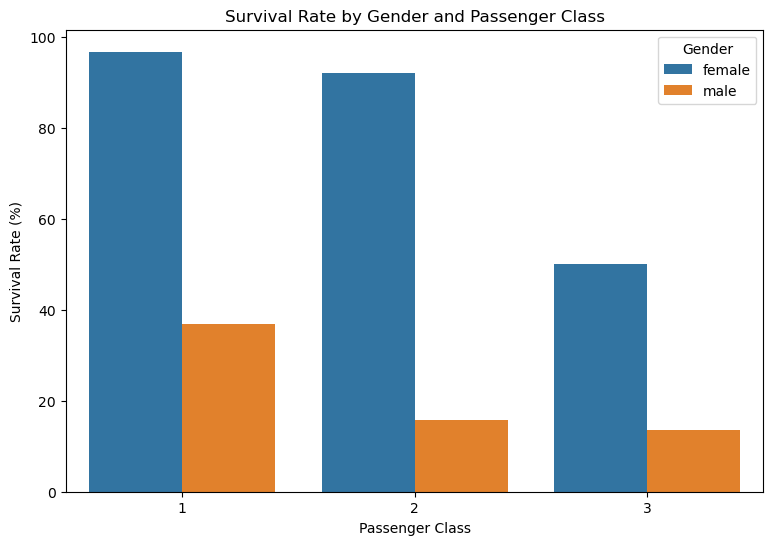

In [24]:
# Survival rate by gender and passenger class

survival_gender_class_df = (
    df.groupby(["Sex", "Pclass"])["Survived"]
    .mean()
    .reset_index()
)

survival_gender_class_df["Survival_Rate"] = (
    survival_gender_class_df["Survived"] * 100
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=survival_gender_class_df,
    x="Pclass",
    y="Survival_Rate",
    hue="Sex"
)

plt.title("Survival Rate by Gender and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate (%)")
plt.legend(title="Gender")

plt.show()

In [25]:
# Create Family Size feature

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

df[["SibSp", "Parch", "FamilySize"]].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [26]:
# Survival rate by family size

family_survival = df.groupby("FamilySize")["Survived"].mean() * 100

family_survival

FamilySize
1     30.353818
2     55.279503
3     57.843137
4     72.413793
5     20.000000
6     13.636364
7     33.333333
8      0.000000
11     0.000000
Name: Survived, dtype: float64

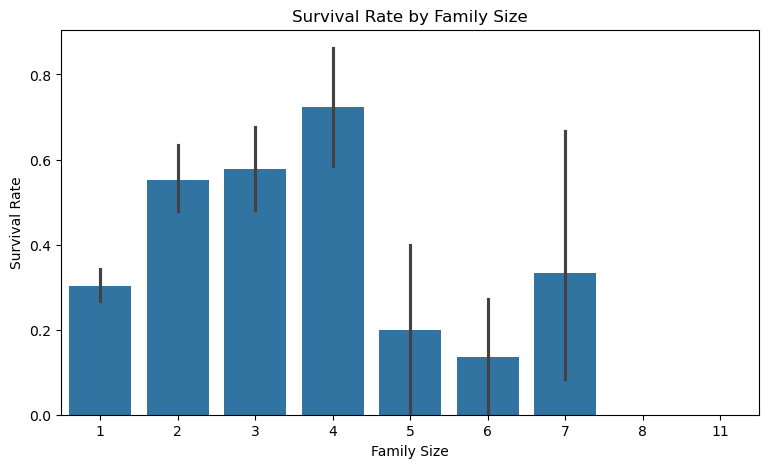

In [27]:
# Survival rate by family size

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="FamilySize",
    y="Survived"
)

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

In [28]:
# Detect Fare outliers using IQR

Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Fare Outliers:", len(fare_outliers))

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344
Number of Fare Outliers: 116


In [29]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [30]:
# Final dataset summary

print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (891, 13)
Duplicate Rows: 0

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
FamilySize       0
dtype: int64

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
FamilySize       int64
dtype: object


In [31]:
# Find the strongest correlations

corr = df.select_dtypes(include="number").corr()

# Remove self-correlations
corr_pairs = corr.where(
    ~np.eye(corr.shape[0], dtype=bool)
).stack().sort_values(ascending=False)

corr_pairs.head(10)

SibSp       FamilySize    0.890712
FamilySize  SibSp         0.890712
            Parch         0.783111
Parch       FamilySize    0.783111
            SibSp         0.414838
SibSp       Parch         0.414838
Fare        Survived      0.257307
Survived    Fare          0.257307
Fare        FamilySize    0.217138
FamilySize  Fare          0.217138
dtype: float64

In [32]:
# Strongest negative correlations

corr_pairs.sort_values().head(10)

Fare        Pclass       -0.549500
Pclass      Fare         -0.549500
            Age          -0.369226
Age         Pclass       -0.369226
Survived    Pclass       -0.338481
Pclass      Survived     -0.338481
Age         SibSp        -0.308247
SibSp       Age          -0.308247
FamilySize  Age          -0.301914
Age         FamilySize   -0.301914
dtype: float64